## Brain Tumor Detection **[Training and Validation]** 


### <b>A. Data Preprocessing</b>


#### Defining the helper functions


In [1]:
import os

train_dir = "../data/brain-tumor-mri-dataset/Training"
test_dir = "../data/brain-tumor-mri-dataset/Testing"
train_paths = []
train_labels = []

1. Generate Sample-Label path arrays


In [ ]:
def generate_label_paths(data_dir):
    image_paths = []
    image_labels = []

    for label in os.listdir(data_dir):
        label_dir = os.path.join(train_dir, label)
        print(f"Total samples for label '{label}': {len(os.listdir(label_dir))}")
        for img_name in os.listdir(label_dir):
            print(
                f"Sample image: {os.path.join(label_dir, img_name)} with label: {label}"
            )
            image_paths.append(os.path.join(label_dir, img_name))
            image_labels.append(label)

    print(f"Number of samples: {len(image_paths)}")
    print(f"Unique labels: {set(image_labels)}")

    return image_paths, image_labels

2. Image Preprocessing helper functions


In [3]:
import random
import numpy as np
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img

I0000 00:00:1778141034.381400   41180 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778141034.406409   41180 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778141036.263959   41180 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


1. Image Augmentation function


In [4]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(
        random.uniform(0.8, 1.2)
    )  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(
        random.uniform(0.8, 1.2)
    )  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

2. Load images and apply augmentation


In [5]:
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

3. Encoding labels (convert label names to integers)


In [6]:
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

4. Data generator for batching


In [7]:
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i : i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i : i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

#### Reading the dataset


In [8]:
from sklearn.utils import shuffle

train_paths, train_labels = generate_label_paths(train_dir)
train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)

Total samples for label 'glioma': 1400
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_10.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_100.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1000.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1001.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1002.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1003.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1004.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1005.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1006.jpg with label: glioma
Sample 

### <b>B. Model Training</b>


<pre>Selecting VGG16 as our Pre-trained model and using Transfer Learning to perform hyperparameter finetuning</pre>


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16

#### Defining trainable parameters for VGG16


In [10]:
IMAGE_SIZE = 128
num_classes = len(os.listdir(train_dir))

# Base Model
base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights="imagenet"
)

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the last few layers (Conv block 5)
for layer in base_model.layers[-4:]:
    layer.trainable = True

W0000 00:00:1778141037.793038   41180 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


#### Defining our final neural network


In [11]:
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [ ]:
model = Sequential(
    [
        Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
        base_model,
        Flatten(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dropout(0.2),  # Dropping 20% of the neurons to prevent overfitting
        Dense(num_classes, activation="softmax"),
    ]
)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)

#### Training our final neural network


In [13]:
# Train
batch_size = 10
epochs = 20
steps = int(len(train_paths) / batch_size)

# datagen is a generator yielding (x_batch, y_batch)
train_dataset = datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs)

history = model.fit(train_dataset, epochs=epochs, steps_per_epoch=steps)

Epoch 1/20


I0000 00:00:1778141038.471674   41180 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


560/560 ━━━━━━━━━━━━━━━━━━━━ 124s 217ms/step - loss: 0.4723 - sparse_categorical_accuracy: 0.8214
Epoch 2/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 96s 172ms/step - loss: 0.2499 - sparse_categorical_accuracy: 0.9087
Epoch 3/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 118s 210ms/step - loss: 0.1672 - sparse_categorical_accuracy: 0.9391
Epoch 4/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 124s 221ms/step - loss: 0.1264 - sparse_categorical_accuracy: 0.9539
Epoch 5/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 123s 220ms/step - loss: 0.0902 - sparse_categorical_accuracy: 0.9636
Epoch 6/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 133s 237ms/step - loss: 0.0922 - sparse_categorical_accuracy: 0.9679
Epoch 7/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 147s 262ms/step - loss: 0.0450 - sparse_categorical_accuracy: 0.9823
Epoch 8/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 145s 258ms/step - loss: 0.0499 - sparse_categorical_accuracy: 0.9818
Epoch 9/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 144s 258ms/step - loss: 0.0433 - sparse_categorical_accuracy: 0.9850
Epoch 10/20
560/560 ━━━━━━━━━━━

### <b>B. Model Validation</b>


#### <b>Figure 1:</b> Model Training Graph (Accuracy vs. Loss)


In [14]:
from matplotlib import pyplot as plt

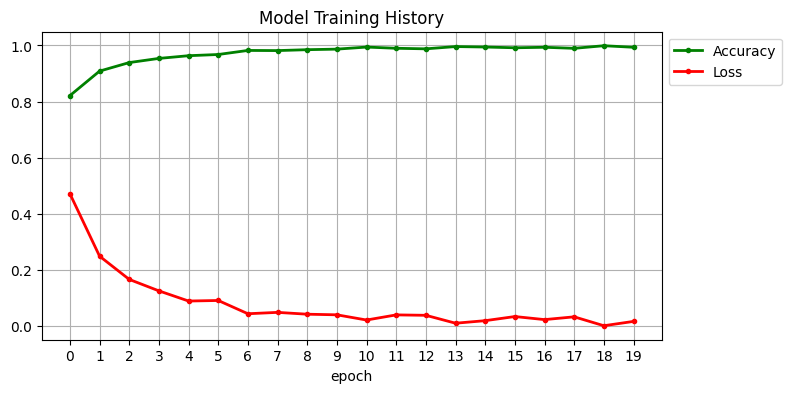

In [15]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history["sparse_categorical_accuracy"], ".g-", linewidth=2)
plt.plot(history.history["loss"], ".r-", linewidth=2)
plt.title("Model Training History")
plt.xlabel("epoch")
plt.xticks([x for x in range(epochs)])
plt.legend(["Accuracy", "Loss"], loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

#### <b>Figure 2:</b> Model Classification Report


In [16]:
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [17]:
test_paths, test_labels = generate_label_paths(test_dir)
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

Total samples for label 'glioma': 1400
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_10.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_100.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1000.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1001.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1002.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1003.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1004.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1005.jpg with label: glioma
Sample image: ../data/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1006.jpg with label: glioma
Sample 

#### <b>Figure 3:</b> Model Confusion Matrix


Confusion Matrix:
[[1387   13    0    0]
 [   0 1399    0    1]
 [   0    3 1394    3]
 [   0    1    0 1399]]


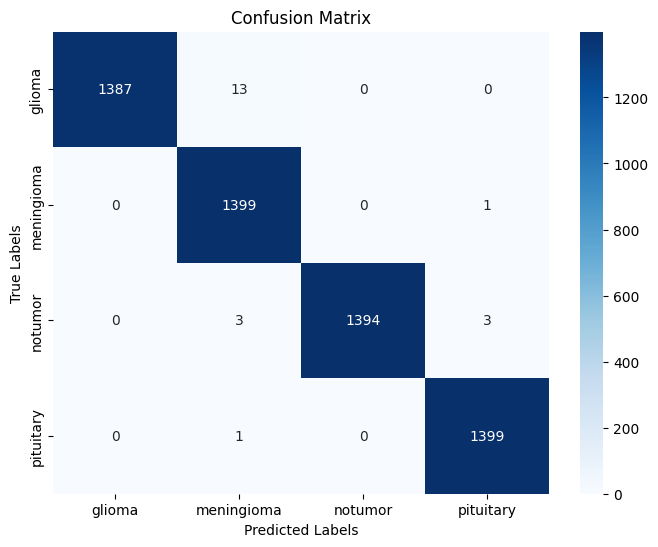

In [18]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=os.listdir(train_dir),
    yticklabels=os.listdir(train_dir),
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#### <b>Figure 4:</b> ROC Curve Plot


In [19]:
test_labels_bin = label_binarize(
    test_labels_encoded, classes=np.arange(len(os.listdir(train_dir)))
)
test_predictions_bin = test_predictions

In [20]:
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

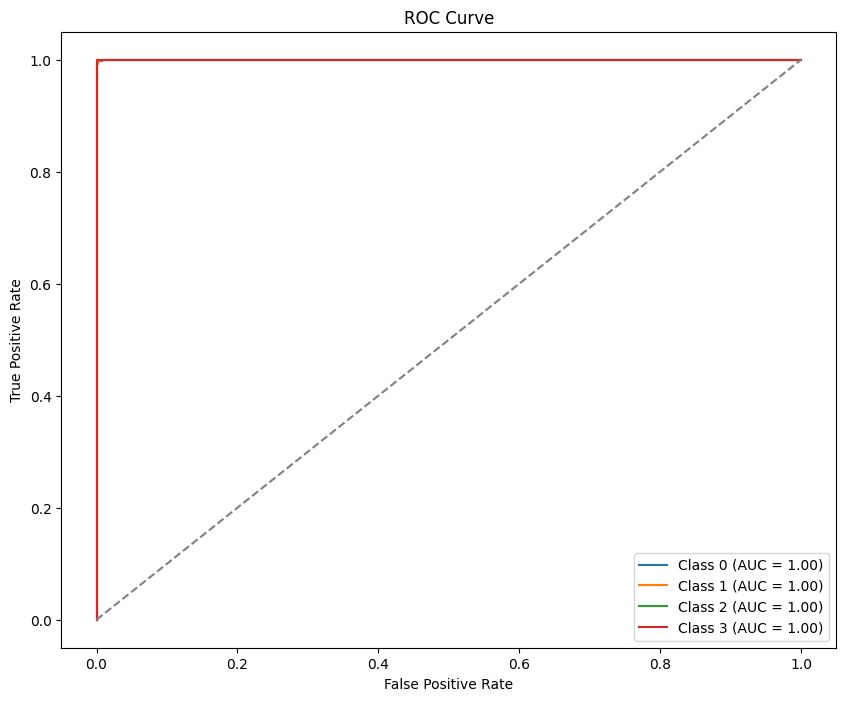

In [21]:
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

#### Saving our trained model


In [22]:
final_accuracy = history.history["sparse_categorical_accuracy"][-1]
final_loss = history.history["loss"][-1]

In [23]:
save_directory = "../models"

if not os.path.exists(save_directory):
    os.makedirs(save_directory)
    print(f"Created directory: {save_directory}")

model_name = f"brain_tumor_vgg16_acc_{final_accuracy:.4f}_loss_{final_loss:.4f}.keras"
full_save_path = os.path.join(save_directory, model_name)

model.save(full_save_path)
print(f"Model saved to: {full_save_path}")

Model saved to: ../models/brain_tumor_vgg16_acc_0.9936_loss_0.0177.keras
